<a href="https://colab.research.google.com/github/RaviduSenavirathna/Sinhala-Word-Recognizer/blob/main/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 1: Added the necessry libs
import os
import numpy as np
import cv2
import tensorflow as tf
import time
import matplotlib.pyplot as plt

from tensorflow.keras import mixed_precision
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

DATASET_DIR = "/content/drive/MyDrive/Sinhala-CNN/processed"   # contains ka/, ga/, la/
IMG_SIZE = (128, 128)     # single letter → square is best
RANDOM_STATE = 42

In [3]:
## Step 2: Set Global Policy for Mixed Precision Training
mixed_precision.set_global_policy('mixed_float16')
print("Global policy:", mixed_precision.global_policy())


Global policy: <DTypePolicy "mixed_float16">


In [4]:
## Step 3: Read an Image with a Unicode Path using OpenCV
def read_image_unicode(path):
    try:
        data = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except Exception as e:
        print("Failed to read:", path, e)
        return None

In [5]:
## Step 4: Load a Dataset of Images from a Directory Structure
# To load a dataset of images from a directory structure, perform pre-processing on each image, and return the images and their corresponding labels as NumPy arrays.

def load_dataset():
    X = []
    y = []

    total_files = 0
    read_ok = 0

    for label in sorted(os.listdir(DATASET_DIR)):
        class_dir = os.path.join(DATASET_DIR, label)
        if not os.path.isdir(class_dir):
            continue

        for fname in os.listdir(class_dir):
            if not fname.lower().endswith(".png"):
                continue

            total_files += 1
            img_path = os.path.join(class_dir, fname)


            img = read_image_unicode(img_path)

            if img is None:
                continue

            read_ok += 1

            #img = img_processing(img)
            img = cv2.resize(img, IMG_SIZE)
            # img = np.stack([img, img, img], axis=-1)
            img = img / 255.0

            X.append(img)
            y.append(label)

    print("Total image files found:", total_files)
    print("Images read successfully:", read_ok)
    print("Images kept:", len(X))

    return np.array(X), np.array(y)


In [6]:
## Step 5: Spliting the Dataset into (train, valid, test)
X, y_text = load_dataset()
le = LabelEncoder()
y = le.fit_transform(y_text)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Total image files found: 1500
Images read successfully: 1500
Images kept: 1500


In [7]:
## Step 6: Create an Optimized tf.data.Dataset
def create_optimized_dataset(X, y, batch_size=32, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_optimized_dataset(X_train, y_train, batch_size=32)
val_dataset = create_optimized_dataset(X_val, y_val, batch_size=32, shuffle=False)

In [8]:
## Step 7: Build and Compile a Transfer Learning Model with ConvNeXtBase
base = tf.keras.applications.ConvNeXtBase(
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    weights="imagenet"
)
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(len(le.classes_), activation="softmax")(x)
model = models.Model(base.input, output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
## Step 8: Train the Model with Callbacks and Report Training Time
callbacks = [
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True),      # save best model
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
]

print("\n Starting training...")
start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,                                  # max epochs
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\n Training complete!")
print(f"   Time: {training_time/60:.1f} minutes")
print(f"   Final val accuracy: {history.history['val_accuracy'][-1]:.4f}")


 Starting training...
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 333s 6s/step - accuracy: 0.2050 - loss: 2.4477 - val_accuracy: 0.3133 - val_loss: 1.9126 - learning_rate: 1.0000e-04
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.6571 - loss: 1.0118 - val_accuracy: 0.6867 - val_loss: 1.4437 - learning_rate: 1.0000e-04
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.7873 - loss: 0.6430 - val_accuracy: 0.8167 - val_loss: 1.1150 - learning_rate: 1.0000e-04
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.8549 - loss: 0.4924 - val_accuracy: 0.8867 - val_loss: 0.8626 - learning_rate: 1.0000e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.8990 - loss: 0.3621 - val_accuracy: 0.9233 - val_loss: 0.6564 - learning_rate: 1.0000e-04
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.9131 - loss: 0.3204 - val_accuracy: 0.9267 - val_loss: 0.5055 - learning_rate: 1.0000e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 1

In [10]:
## Step 9: Save the Trained Model
model.save("/content/drive/MyDrive/Sinhala-CNN/sinhala_convnext.keras")

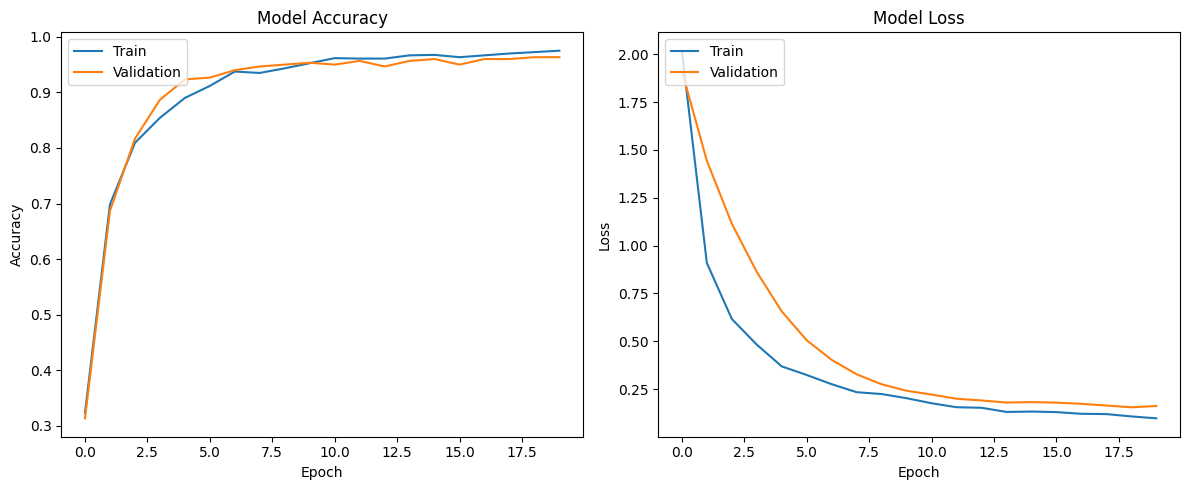

In [11]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()
